# Notebook that performs batch GPU-accelerated resampling of VLBI observation data.

- Notebook that iterates across all VLBI scans in an observation, copying input HDF5 files, resampling them with the GPU-accelerated code, and transferring the VDIF files to the remote server.

Rev 3:
- integrating new catalogue parsing and testing.
- added circular pol conversion.

Rev 4:
- updated catalogue parsing function for phase-up correction parameters in schedule file header.
- ignoring phase-up correction scans during processing.
- addressing case-sensitivity on calscan_prefix


In [1]:
# Experiments

# EVN Session 3 2024
# n24l3, 1729171747

# EVN Session 1 2025:
# n25l1, 1740055990
# em181a, 1740224791
# es116a, 1740943459

# EVN Session 2 2025:
# n25l2: 1749383603
# em180a: 1749409153
# ed051a: 1749724290
# em180b: 1749814757

# LBA test, 14-08-2025
# vt33a: 1755154278

# EVN Session 3 2025
# n25l3 comments: 
# - Note that there are distinct CSV catalogue files for 18 and 21cm. Rename each appropriately when doing analysis for that band.
# - Except for the cal scans, there's no need to rename the power output files since these are labelled per scan. Cal scans with the same
#   number from different observations will be overwritten, though that doesn't really matter. In future, use different cal scan numbers 
#   in the different observations.
# - the auxiliary files however require significant changes, as both observations need to be combined into one file.
# n25l3, 1761049693 (18cm).  
# n25l3, 1761056293 (21cm).
# el079b, 1761145885
# gg090, 1761508048


In [2]:
# Main parameters

# VLBI observation capture block ID
obs_cbid = '1769593762' 
# VLBI Experiment name (sets the output folder / file names)
exp_name = 'pcctest'
# Optional indentifier appended to output folder name to distinguish data from different algorithms
code_id = ''
# Station name (used in folder / file names)
station_name = 'me'

# LOCAL directory for storing hdf5 files
hdf5_dir = '/scratch/mgouws/hdf5_captures/'
# REMOTE hdf5 dir where extracted hdf5 scan files are stored.
# - VBP1 high-speed IP: 10.98.6.112, host name: vbp1.sdp.mkat.karoo.kat.ac.za
remote_hdf5_dir = 'kat@10.98.6.112:/scratch/mgouws/hdf5_scans/'
# LOCAL VDIF output directory
vdif_dir = '/scratch/mgouws/vdif_output/'
# REMOTE VDIF directory to where processed VDIF data is uploaded 
remote_vdif_dir = 'mgouws@196.24.105.52:/mnt/disk0/'
# Observation catalogue directory
cat_dir = '/home/mgouws/vlbi/catalogues/'
# Location of VLBI channel power files (stored per scan)
pwr_dir = '/home/mgouws/vlbi/pwr_files/'
# Location to download rdb files
rdb_dir = '/home/mgouws/vlbi/rdb_files/'

# Overall observation data conversion loop
process_observation = True
# Analyse overall observation conversion data
analyse_observation = True

# Set whether to resample data
convert_data = True
# Set whether to copy created VDIF files to remote server
transfer_vdif = True
# Set whether to delete local files for a scan after processing.
delete_local_hdf5 = True
delete_local_vdif = True


In [3]:
# Imports and definitions

import numpy as np
import matplotlib.pyplot as plt
import os.path
import os
import time
import requests
from datetime import datetime, timedelta, timezone
from baseband import vdif
import astropy.units as u
import katpoint

def parse_vlbi_cat(vlbi_cat_fn, proc_buffer_sec=1, ref_ant=None):
    """ Parses the provided VLBI catalogue file and provides a list of scan parameters and
    a katpoint catalogue of unique targets in the observation. 

    Parameters
    ----------
    vlbi_cat_fn : string
        Location of text file containing observation scan information
    proc_buffer_sec : integer 
        Buffer time in seconds added before and after processing start and 
        stop time. 
    ref_ant : katpoint Antenna object
        Reference antenna for katpoint Catalogue

    Returns
    -------
    obs_params : Dictionary
        Dictionary with observation parameters.
    scan_params : list of dictionaries
        List of dictionaries with paramters for each scan.
    vlbi_cat : katpoint Catalogue object
        katpoint catalogue with unique targets to be observed.
        
    """
    # Read the VLBI catalogue file 
    with open(vlbi_cat_fn, 'r') as cat_file:
        csv_lines = [line for line in cat_file.readlines()]
    # Read header info
    header_lines = [line[1:].strip() for line in csv_lines if line.startswith('#')]
    hdr_keys = ['EXPERIMENT', 'POL', 'CAL_PREFIX', 'PCC_PREFIX', 'PCC_VERIFICATION'] 
    obs_params = dict.fromkeys(hdr_keys)
    obs_params['CHANNELS'], hdr_ch_key = {}, 'CH'
    for line in header_lines:
        hdr_key, hdr_par = line.split(' ')[0], line.split(' ')[1:]
        if hdr_key in hdr_keys:
            obs_params[hdr_key] = ' '.join(hdr_par)
        elif line.startswith(hdr_ch_key):
            obs_params['CHANNELS'][hdr_key] = hdr_par
    # Create list of scan parameters
    scan_params = {}
    scan_lines = [line for line in csv_lines if not line.startswith('#')]
    for scan_line in scan_lines:
        # Scan name
        scan_name = scan_line.split(',')[-3].strip()
        # Datetime of scan start time
        start_time_str = scan_line.split(',')[-2].strip()
        start_time = datetime.strptime(start_time_str, '%Y-%m-%d %H:%M:%S.%f')
        start_time = start_time.replace(tzinfo=timezone.utc)
        # Start time for processing of scan
        start_time_proc = start_time - timedelta(seconds=proc_buffer_sec)  
        # Duration
        duration = int(scan_line.split(',')[-1])
        # Target name
        tgt_string = scan_line.split(',')[0].split('|')[0].strip()
        tgt_string = tgt_string[1:] if tgt_string.startswith('*') else tgt_string
        # Create a katpoint target line
        kp_target_ln = ', '.join([kp.strip(' ') for kp in scan_line.split(',')[:-3]]) 
        # Store scan parameters
        scan_params[scan_name] = {'target':tgt_string,
                                  'start_iso':scan_line.split(',')[-2],
                                  'start_ts':start_time.timestamp(),
                                  'duration':duration,
                                  'kp_tgt':katpoint.Target(kp_target_ln, antenna=ref_ant),
                                  'proc_start_iso':start_time_proc.strftime('%Y-%m-%dT%H:%M:%S.%f'),
                                  'proc_start_ts':start_time_proc.timestamp(),                               
                                  'proc_duration':duration+2*proc_buffer_sec}
    # Sort dictionary entries by scan start time
    sorted_params = sorted(scan_params.items(), key=lambda e:e[1]['start_ts'])
    scan_params = dict(sorted_params)
    # Create a katpoint catalogue for unique targets
    kp_target_list = []
    for scan_name, scan_pars in scan_params.items():
        if scan_pars['kp_tgt'] not in kp_target_list:
            kp_target_list.append(scan_pars['kp_tgt'])
    vlbi_cat = katpoint.Catalogue(kp_target_list, antenna=ref_ant)
    return obs_params, scan_params, vlbi_cat


def parse_chan_params(vex_params, chan_map):
    """ Parse channel parameters read from a VLBI observation catalogue 
    file and compute frequency parameters required for pipeline 
    post-processing. FIXME: This is only valid for a 2-channel band
    and needs to be updated to accommodate expanded channels.

    Parameters
    ----------
    vex_params : Dictionary
        Dictionary with VEX-file parameters as read from VLBI catalogue 
        header.
    chan_map : Dictionary 
        Dictionary mapping the antab-standard channel names to the 
        channel names used in pipeline-generated channel power files. 

    Returns
    -------
    fc_band : float
        Value of the VLBI band center frequency in Hz.
    bw_chan : float
        Value of the VLBI channel bandwidth in Hz.
    fc_chans : Dictionary
        Dictionary indexed by power-file channel names containing.
        the center frequency of each in Hz.
    antab_chan_def : Dictionary
        Dictionary indexed by antab-file channel names containing.
        parameters required within the antab file.
    
    """
    fc_chans, chan_def = {}, {}
    for vex_ch_desc in vex_params['CHANNELS'].values():
        fc_band_MHz, sb_chan, bw_chan_MHz, pol_chan = vex_ch_desc
        fc_band_MHz, bw_chan_MHz = float(fc_band_MHz), float(bw_chan_MHz)
        fc_chan_MHz = fc_band_MHz-bw_chan_MHz/2.0 if sb_chan=='LSB' else fc_band_MHz+bw_chan_MHz/2.0
        # Channel name as per Tsys file header
        tsys_pol_name = 'pol0' if pol_chan=='RCP' else 'pol1'
        tsys_ch_name = sb_chan.lower()+'-'+tsys_pol_name 
        # Channel center frequency in Hz 
        fc_chans[tsys_ch_name] = fc_chan_MHz*1e6
        # Antab info: channel_name:[fc_chan, sideband, bw_chan]
        chan_def[tsys_ch_name] = [fc_chan_MHz, sb_chan, bw_chan_MHz]
    # Remap antab chan definition with antab channel names
    antab_chan_def = {antab_ch:chan_def[chan_map[antab_ch]] for antab_ch in chan_map.keys()}
    return fc_band_MHz*1e6, bw_chan_MHz*1e6, fc_chans, antab_chan_def


In [4]:
#  Load observation metadata

# VLBI CSV catalogue file name
vlbi_cat_file = 'vlbi_cat_{}.csv'.format(exp_name)
# Load and parse observation VLBI catalogue
vex_params, scan_data, _ = parse_vlbi_cat(cat_dir+vlbi_cat_file)
# Read phase-correction scan prefix.
try:
    pcc_prefix = vex_params['PCC_PREFIX'].lower()
except:
    print("WARNING: PCC prefix undefined.")
    pcc_prefix = None
# Set scan names
scan_names = list(scan_data.keys())
# Filter scan names to exclude PCC scans, since these must not be processed.
if pcc_prefix:
    scan_names = [sn for sn in scan_names if not sn.lower().startswith(pcc_prefix)]

# Read observation parameters from catalogue file header
if np.any(vex_params.values() is None) or len(vex_params['CHANNELS'])==0:
    # VEX file parameters have to be defined in the catalogue header.
    raise("Invalid observation catalogue header.")
else:
    # Define mapping of antab channel labels to Tsys file channel labels:
    # - antab channel label must be 'R' or 'L' followed by an integer.
    antab_chan_map = {'R1':'lsb-pol0', 'L1':'lsb-pol1',
                      'R2':'usb-pol0', 'L2':'usb-pol1'}
    parse_result = parse_chan_params(vex_params, antab_chan_map)
    fc_band, bw_chan, fc_chans, antab_chan_def = parse_result
    bw_band = 2*bw_chan
    # Flag to convert antab Tsys values to cicular pol
    apply_l2c_conversion = vex_params['POL']=='RL'  # FIXME NOT IMPLEMENTED 
    calscan_prefix = vex_params['CAL_PREFIX'].lower()
    print("Observation parameters:")
    print("- band center frequency: {}, bandwidth {} ".format(fc_band, bw_band))
    print("- linear-to-circular conversion: {}".format(apply_l2c_conversion))
    print("- calibration scan prefix: {}".format(calscan_prefix))
    print()

# Print catalogue for inspection
print('Catalogue overview ({}):'.format(vlbi_cat_file))
with open(cat_dir+vlbi_cat_file, 'r') as cat_file:
    scan_lines = [line for line in cat_file.readlines() if not line.startswith('#')]
    for scan_line in scan_lines:
        print(scan_line, end='')
    print()

# Set RDB address and file name
addr_rdb = 'http://archive-gw-1.kat.ac.za/'+obs_cbid+'/'+obs_cbid+'_sdp_l0.full.rdb'
fn_rdb = rdb_dir+obs_cbid+'_sdp_l0.full.rdb'
# Download RDB file
if not os.path.exists(fn_rdb):
    !wget -P $rdb_dir $addr_rdb

# Set experiment directories
hdf5_exp_dir = hdf5_dir+exp_name+'/'
if not os.path.exists(hdf5_exp_dir):
    os.mkdir(hdf5_exp_dir)
vdif_exp_dir = vdif_dir if code_id=='' else vdif_dir[:-1]+'_'+code_id+'/'
if not os.path.exists(vdif_exp_dir):
    os.mkdir(vdif_exp_dir)


Observation parameters:
- band center frequency: 1626490000.0, bandwidth 64000000.0 
- linear-to-circular conversion: False
- calibration scan prefix: mcal

Catalogue overview (vlbi_cat_pcctest.csv):
J1939-6342 | PKS1934-638 | PKS 1934-63, radec bfcal single_accumulation, 19:39:25.02671, -63:42:45.6255, (408.0 8640.0 -30.76 26.49 -7.098 0.6053), mpcc No0000, 2026-01-28 09:50:00.000, 120 
J1859-6615 | 1854-663, radec, 18:59:57.94, -66:15:02.3, (145. 20000. -5.3678 5.9491 -1.7969 0.1492), scan No0000, 2026-01-28 10:04:00.000, 120 
J1744-5144 | 1740-517, radec, 17:44:25.4549, -51:44:43.740, (145. 99000. -3.6941 2.7447 -0.3655 -0.015), scan No0001, 2026-01-28 10:07:00.000, 120 
J1939-6342 | PKS1934-638 | PKS 1934-63, radec bfcal single_accumulation, 19:39:25.02671, -63:42:45.6255, (408.0 8640.0 -30.76 26.49 -7.098 0.6053), mpcc No0001, 2026-01-28 10:10:00.000, 120 
J1859-6615 | 1854-663, radec, 18:59:57.94, -66:15:02.3, (145. 20000. -5.3678 5.9491 -1.7969 0.1492), scan No0002, 2026-01-28 1

In [5]:
# Download / resampling / upload loop

if process_observation:

    # Variables for tracking execution time
    p_times = np.zeros(3)
    p_time_start = time.time()

    # Loop over scans
    for scan_name in scan_names:
    
        print("=======================================================")
        print("Processing {}...".format(scan_name))    
        print("=======================================================")
        
        # Set HDF5 file names 
        inst_hdf5_fn = '_narrow1_tied_array_channelised_voltage_0'
        scan_str = "".join(scan_name.split())
        fn_h5_x = obs_cbid+inst_hdf5_fn+'x_'+scan_str+'.h5'
        fn_h5_y = obs_cbid+inst_hdf5_fn+'y_'+scan_str+'.h5'
    
        # Set local HDF5 file locations
        loc_h5_x = hdf5_exp_dir + fn_h5_x
        loc_h5_y = hdf5_exp_dir + fn_h5_y

        # Execution time tracking: hdf5 file copying
        tick = time.time()
        
        # Download HDF5 files for the specified scan name 
        if os.path.exists(loc_h5_x):
            print('HDF5 file already copied: {}'.format(fn_h5_x))
        else:
            print('Copying {}... '.format(fn_h5_x), end='')
            remote_hdf5_loc = remote_hdf5_dir + fn_h5_x
            !sshpass -p 'kat' scp -r $remote_hdf5_loc $hdf5_exp_dir
            print('done.')
        if os.path.exists(loc_h5_y):
            print('HDF5 file already copied: {}'.format(fn_h5_y))
        else:
            print('Copying {}... '.format(fn_h5_y), end='')
            remote_hdf5_loc = remote_hdf5_dir + fn_h5_y
            !sshpass -p 'kat' scp -r $remote_hdf5_loc $hdf5_exp_dir
            print('done.')

        # Execution time tracking: hdf5 file copying
        p_times[0] += time.time() - tick
    
        # Create VDIF output directory
        scan_num_str = scan_name.split()[-1]
        vdif_scan_dir = vdif_exp_dir+exp_name+'_'+station_name+'_'+scan_num_str+'/'
        if not os.path.exists(vdif_scan_dir):
            os.mkdir(vdif_scan_dir)
            print('created', vdif_scan_dir)
            
        # Set VDIF output file pattern
        vdif_out_str = vdif_scan_dir+exp_name+'_'+station_name+'_'+scan_num_str+'.{file_nr:08d}'
    
        # Set output power file name
        pwrvals_fn = pwr_dir+exp_name+'_'+scan_name.replace(' ', '')+'_pwr.csv'
        
        # Print information extracted from the catalogue for the specified scan
        print("{} resampling start: {}, duration {}".format(scan_name, scan_data[scan_name]['proc_start_iso'], 
                                                            scan_data[scan_name]['proc_duration']))

        # Execution time tracking: Data conversion
        tick = time.time()
        
        # Run GPU-accelerated VLBI resampling script
        if convert_data and not apply_l2c_conversion:
            
            # DO NOT apply linear-to-circular polarisation conversion
            arg_starttime = scan_data[scan_name]['proc_start_iso']
            arg_duration = scan_data[scan_name]['proc_duration']
            print("Running GPU VDIF conversion...")
            !mk_vlbi_resample $loc_h5_y $loc_h5_x $vdif_out_str --telstate=$fn_rdb \
            --samples-per-frame 20000 \
            --bandwidth $bw_band --frequency $fc_band --fir-taps 7201 \
            --start $arg_starttime --duration $arg_duration \
            --record-power=$pwrvals_fn \
            --normalise='auto' \
            --time-correction=0us
            
        elif convert_data and apply_l2c_conversion:
            
            # Apply linear-to-circular polarisation conversion
            arg_starttime = scan_data[scan_name]['proc_start_iso']
            arg_duration = scan_data[scan_name]['proc_duration']
            print("Running GPU VDIF conversion (circular pol conversion enabled)...")
            !mk_vlbi_resample $loc_h5_y $loc_h5_x $vdif_out_str --telstate=$fn_rdb \
            --samples-per-frame 20000 \
            --bandwidth $bw_band --frequency $fc_band --fir-taps 7201 \
            --start $arg_starttime --duration $arg_duration \
            --record-power=$pwrvals_fn \
            --normalise='auto' \
            --time-correction=0us \
            --polarisation='x,y:R,L'         

        # Execution time tracking: Data conversion
        p_times[1] += time.time() - tick 
        # Execution time tracking: VDIF copying
        tick = time.time()
        
        # Copy created VDIF files to remove VLBI server
        transfer_scan_dir = vdif_scan_dir[:-1] if vdif_scan_dir[-1]=='/' else vdif_scan_dir
        if transfer_vdif:
            skip_transfer = scan_name.lower().startswith(calscan_prefix)
            if skip_transfer:
                print("Skipping transfer of {}.".format(scan_name))
            else:
                print("Transferring {} to remote server.".format(transfer_scan_dir))
                #!rsync -rv --dry-run $transfer_scan_dir $remote_vdif_dir
                !rsync -rv $transfer_scan_dir $remote_vdif_dir

        # Execution time tracking: Data conversion
        p_times[2] += time.time() - tick 
    
        # Delete local VDIF files
        if delete_local_hdf5:
            print('Deleting {}... '.format(loc_h5_x), end='')
            !rm $loc_h5_x
            print('done.')
            print('Deleting {}... '.format(loc_h5_y), end='')
            !rm $loc_h5_y
            print('done.')
            
        # Delete local VDIF scans
        if delete_local_vdif:
            print('Deleting {}... '.format(transfer_scan_dir), end='')
            !rm -r $transfer_scan_dir
            print('done.')

    p_time_total = time.time() - p_time_start
    print("TOTAL execution time: {:.2f} min".format(p_time_total/60.0))
    print("- hdf5 copying: {:.2f} min".format(p_times[0]/60.0))
    print("- data conversion: {:.2f} min".format(p_times[1]/60.0))
    print("- vdif copying: {:.2f} min".format(p_times[2]/60.0))


Processing scan No0000...
Copying 1769593762_narrow1_tied_array_channelised_voltage_0x_scanNo0000.h5... done.
done.ng 1769593762_narrow1_tied_array_channelised_voltage_0y_scanNo0000.h5... 
created /scratch/mgouws/vdif_output/pcctest_me_No0000/
scan No0000 resampling start: 2026-01-28T10:03:59.000000, duration 122
Running GPU VDIF conversion...
⠼ Loading telescope state parameters.....
Processing... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:0000:0100:04
Transferring /scratch/mgouws/vdif_output/pcctest_me_No0000 to remote server.
sending incremental file list
pcctest_me_No0000/
pcctest_me_No0000/pcctest_me_No0000.00000000
pcctest_me_No0000/pcctest_me_No0000.00000001
pcctest_me_No0000/pcctest_me_No0000.00000002
pcctest_me_No0000/pcctest_me_No0000.00000003
pcctest_me_No0000/pcctest_me_No0000.00000004
pcctest_me_No0000/pcctest_me_No0000.00000005
pcctest_me_No0000/pcctest_me_No0000.00000006
pcctest_me_No0000/pcctest_me_No0000.00000007
pcctest_me_No0000/pcctest_me_No0000.00000008
pcc

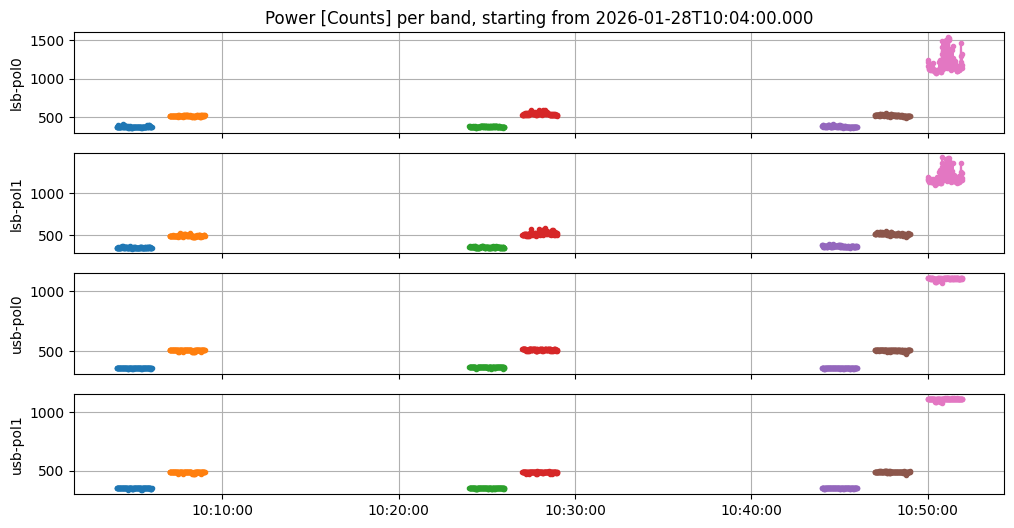

In [6]:
# Overview analysis of created VDIF files

if analyse_observation:

    # Plot saved power levels
    from astropy.time import Time as ap_time
    from matplotlib.dates import DateFormatter
    import pandas as pd

    fig, axs = plt.subplots(4,1, figsize=(12,6), sharex=True)
    plt_start_time = None
    pwrvals_fns = [pwr_dir+exp_name+'_'+scan_name.replace(' ', '')+'_pwr.csv' for scan_name in scan_names]
    for pwrvals_fn in pwrvals_fns:
    
        try:
            # Load CSV data with pandas
            df = pd.read_csv(pwrvals_fn)
            hdr_keys = df.keys().to_list()
            
            t_strlist = list(df['time'].array)
            t_axis = ap_time(t_strlist, format='isot') 
            if plt_start_time is None:
                plt_start_time = t_axis[0]
            for ii, key in enumerate(hdr_keys[1:]):
                axs[ii].plot(t_axis.to_datetime(), df[key].array, '.-')
        
        except Exception as e:
            print(e)
            pass

    for ii in range(4):
        axs[ii].grid(), axs[ii].set_ylabel(hdr_keys[ii+1]), 
    axs[-1].xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
    axs[0].set_title('Power [Counts] per band, starting from '+str(plt_start_time))
    plt.show()

